#  Credit Default Risk Prediction

## 📋 Table of Contents
1. [Setup & Data Loading](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Preprocessing & Feature Engineering](#3)
4. [Handling Class Imbalance](#4)
5. [Baseline Model — Logistic Regression](#5)
6. [Advanced Models — XGBoost & LightGBM](#6)
7. [Hyperparameter Tuning with Optuna](#7)
8. [Model Evaluation & Threshold Tuning](#8)
9. [Explainability with SHAP](#9)
10. [Scorecard & Final Submission](#10)

<a id='1'></a>
## 1. Setup & Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('✅ All imports successful')

✅ All imports successful


In [3]:
# Load data
train_raw = pd.read_csv('cs-training.csv', index_col=0)
test_raw  = pd.read_csv('cs-test.csv',  index_col=0)

print(f'Training shape : {train_raw.shape}')
print(f'Test shape     : {test_raw.shape}')
train_raw.head()

Training shape : (150000, 11)
Test shape     : (101503, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
# data types & non-null counts
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

The data set only has numerical values

In [5]:
# Summary statistics
train_raw.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.000000,0.066840,0.249746,0.000000,0.000000,0.000000,0.000000,1.000000
RevolvingUtilizationOfUnsecuredLines,150000.000000,6.048438,249.755371,0.000000,0.029867,0.154181,0.559046,50708.000000
age,150000.000000,52.295207,14.771866,0.000000,41.000000,52.000000,63.000000,109.000000
NumberOfTime30-59DaysPastDueNotWorse,150000.000000,0.421033,4.192781,0.000000,0.000000,0.000000,0.000000,98.000000
DebtRatio,150000.000000,353.005076,2037.818523,0.000000,0.175074,0.366508,0.868254,329664.000000
MonthlyIncome,120269.000000,6670.221237,14384.674215,0.000000,3400.000000,5400.000000,8249.000000,3008750.000000
NumberOfOpenCreditLinesAndLoans,150000.000000,8.452760,5.145951,0.000000,5.000000,8.000000,11.000000,58.000000
NumberOfTimes90DaysLate,150000.000000,0.265973,4.169304,0.000000,0.000000,0.000000,0.000000,98.000000
NumberRealEstateLoansOrLines,150000.000000,1.018240,1.129771,0.000000,0.000000,1.000000,2.000000,54.000000
NumberOfTime60-89DaysPastDueNotWorse,150000.000000,0.240387,4.155179,0.000000,0.000000,0.000000,0.000000,98.000000




The dataset has **150,000 borrowers** and **11 features**. A few things immediately stand out:

**Target:** Only 6.7% of borrowers defaulted — meaning the data is heavily imbalanced. 
We cannot rely on accuracy as a metric here.

**Outliers are a real problem:**
- `RevolvingUtilization` should be between 0–1 (it's a percentage) but hits **50,708** — clearly wrong
- `DebtRatio` median is a healthy 0.37 but the max is **329,664** — extreme outliers driven by near-zero incomes
- The three delinquency columns all max out at **98**, which is impossible in a 2-year window — these are coded missing values, not real counts

**Missing data:**
-`MonthlyIncome` is the biggest concern — **~20% of values are missing**
-`NumberOfDependents` is only missing 2.6% — minor issue

**Age looks fine** — mean and median are both around 52, which means it's evenly distributed. 
The only exception is a minimum age of **0**, which is clearly a data entry error.

**Income is right-skewed** — the mean ($6,670) is higher than the median ($5,400), meaning 
a few high earners are pulling the average up. A log transform will fix this.

> All of these issues are handled in the preprocessing step below.

<a id='2'></a>
## 2. Exploratory Data Analysis (EDA)

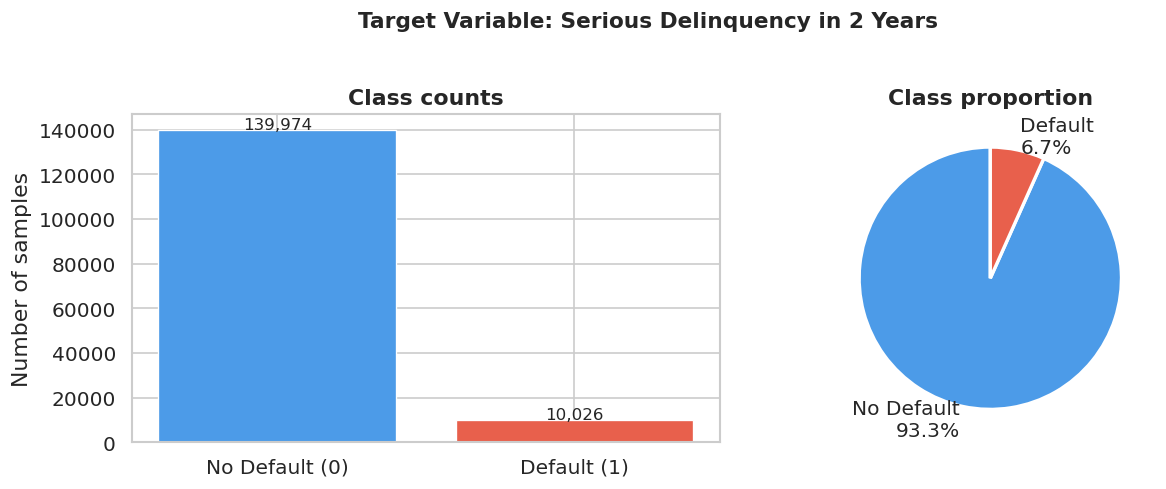


Class imbalance ratio  :  1 : 14.0
Default rate           :  6.68%


In [6]:
# Target variable distribution

TARGET = 'SeriousDlqin2yrs'

counts = train_raw[TARGET].value_counts()
pct    = train_raw[TARGET].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['No Default (0)', 'Default (1)'], counts.values,
            color=['#4C9BE8', '#E8604C'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Class counts', fontweight='bold')
axes[0].set_ylabel('Number of samples')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(pct.values, labels=[f'No Default\n{pct[0]:.1f}%', f'Default\n{pct[1]:.1f}%'],
            colors=['#4C9BE8', '#E8604C'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class proportion', fontweight='bold')

plt.suptitle('Target Variable: Serious Delinquency in 2 Years', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nClass imbalance ratio  :  1 : {counts[0]/counts[1]:.1f}')
print(f'Default rate           :  {pct[1]:.2f}%')

The bar chart and pie chart above show the same story from two angles.

Out of 150,000 borrowers, only about **10,000 defaulted** — the rest stayed current.
That gives us a roughly **14:1 ratio** of non-defaulters to defaulters.

This is completely normal in credit risk — banks would go out of business if 50% 
of borrowers defaulted! But it creates a challenge for our model:

> If the model will just predict "No Default" for everyone, it would still be 
> **~93% accurate** — yet completely useless for catching real defaulters.

This is why **accuracy is the wrong metric** for this problem. I will use:
- **AUC-ROC**   to measure how well the model separates defaulters from non-defaulters
- **PR-AUC**   to measure how well it performs specifically on the minority (default) class
- **Recall**  to find out if i am catching the actual defaulters.

And why I need strategies like **SMOTE** and **class weighting** will be  covered in Step 4.

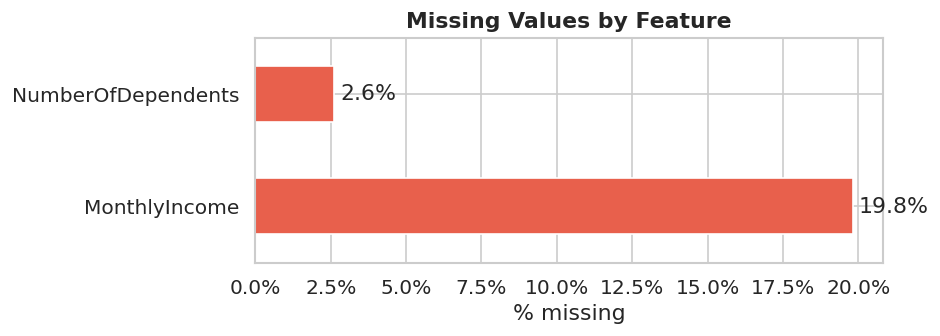


Missing value counts:
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


In [7]:
# Missing values
missing = (train_raw.isnull().sum() / len(train_raw) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 3))
missing.plot(kind='barh', color='#E8604C', ax=ax)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Missing Values by Feature', fontweight='bold')
ax.set_xlabel('% missing')
for i, v in enumerate(missing.values):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

print('\nMissing value counts:')
print(train_raw.isnull().sum()[train_raw.isnull().sum() > 0])

Only two features have missing data — which is actually quite clean for a real-world dataset.

**`MonthlyIncome` (~19.8% missing)** is the serious one. One in five borrowers has no 
income recorded. This could mean they were unemployed, self-employed, or it was simply 
not collected. We cannot drop these rows — that's 30,000 borrowers lost. 
Instead we fill with the **median income ($5,400)**.

**`NumberOfDependents` (~2.6% missing)** is minor. Given that the median is 0, 
most people with missing values likely just have no dependents. 
We fill with the **mode (0)**.

> Everything else is complete — no other missing values across 150,000 rows.

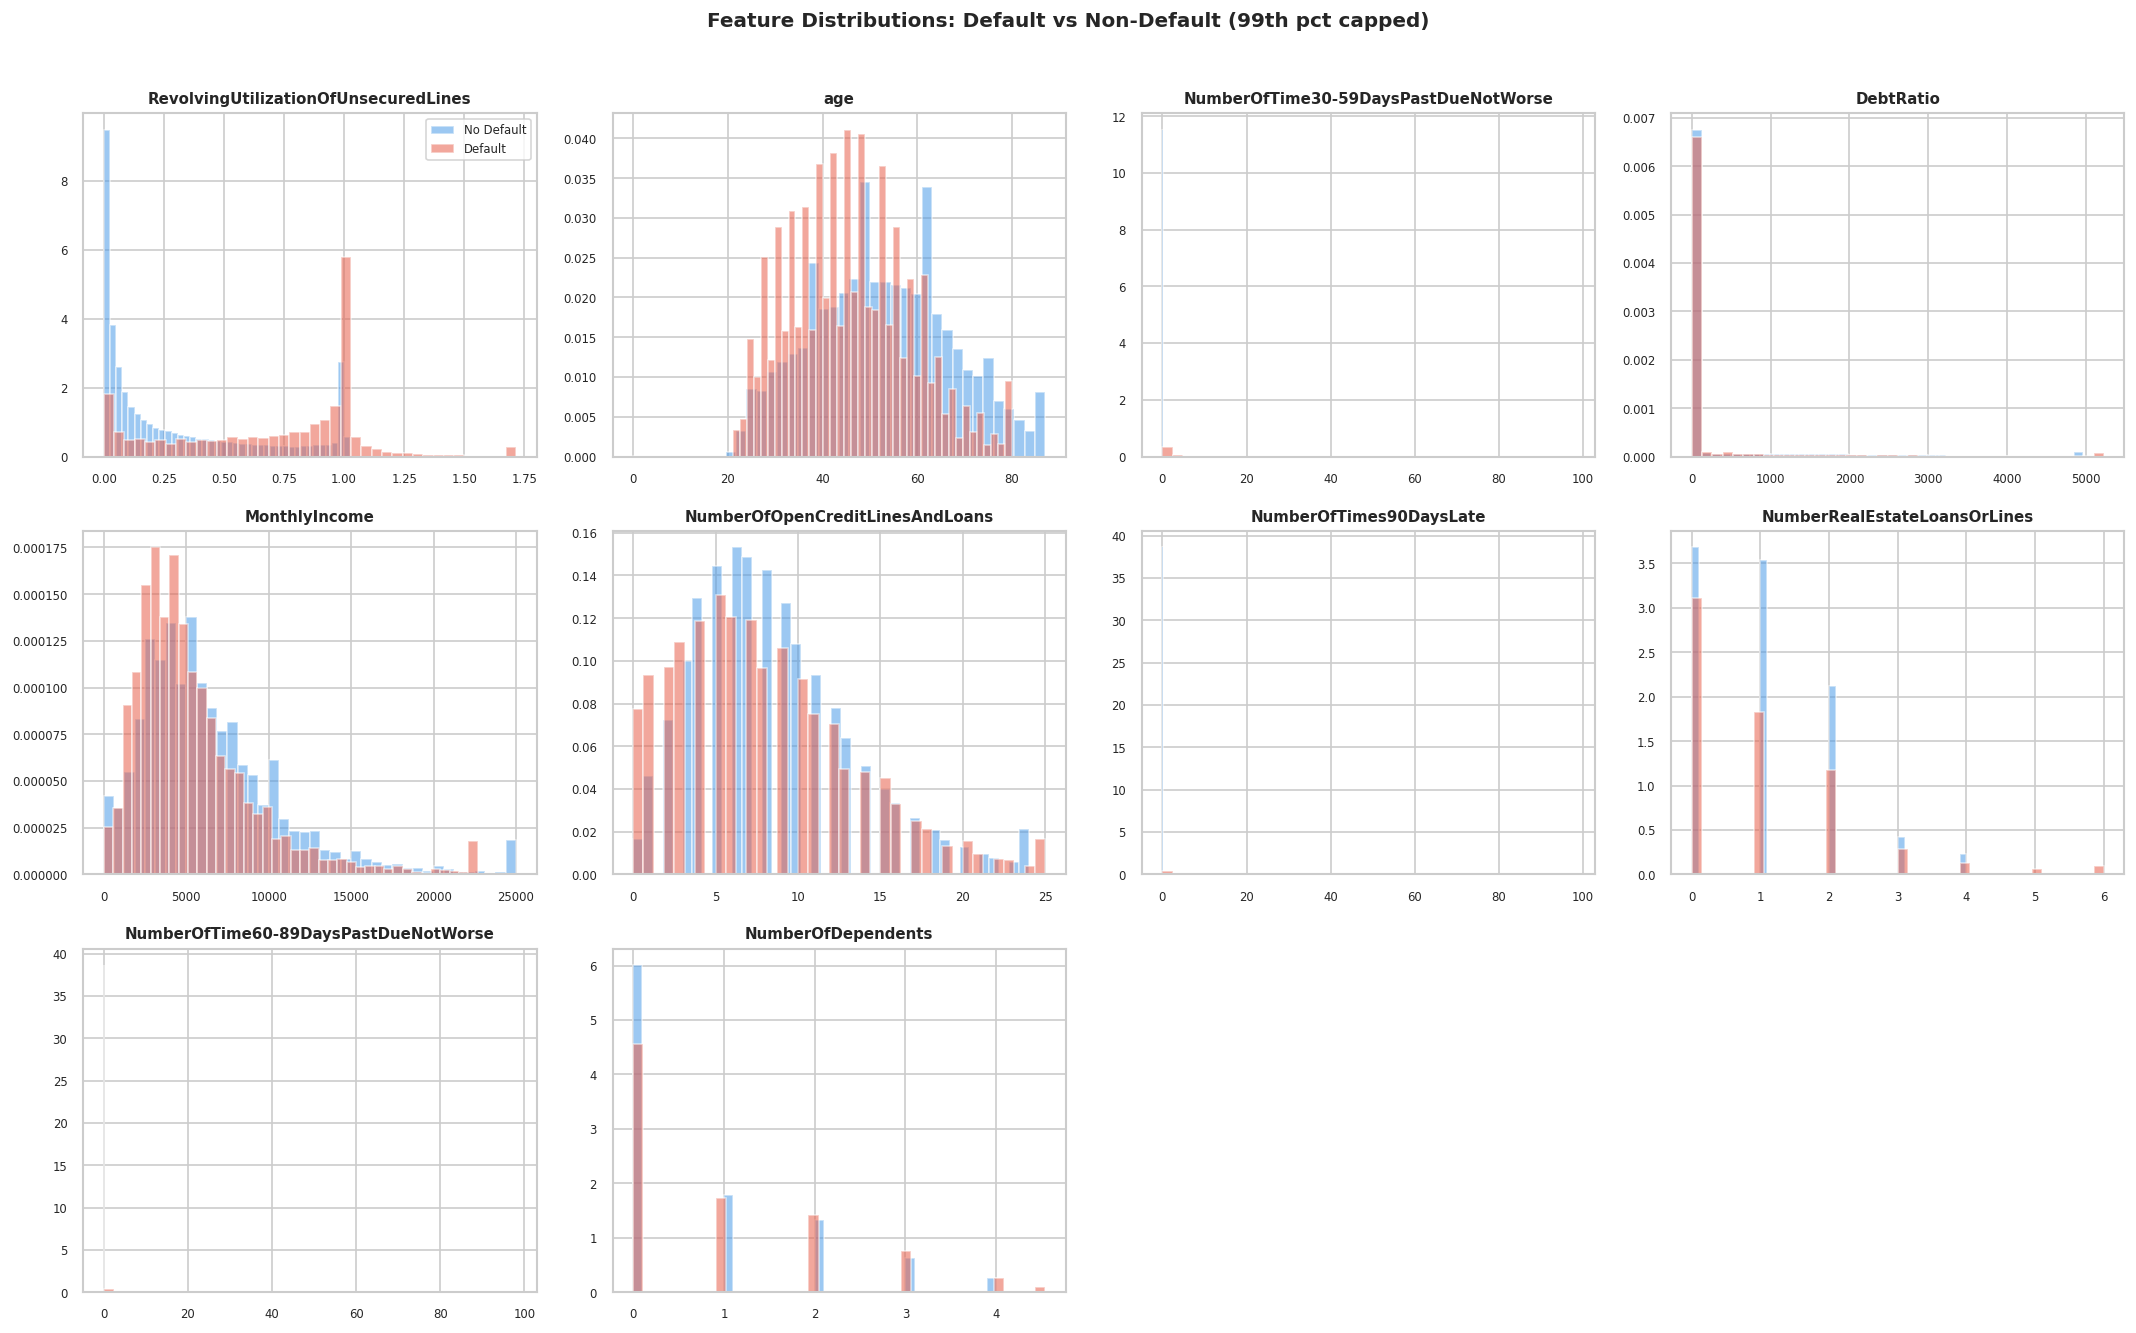

In [8]:
# Feature distributions
FEATURES = [c for c in train_raw.columns if c != TARGET]

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    ax = axes[i]
    for label, color in [(0, '#4C9BE8'), (1, '#E8604C')]:
        subset = train_raw[train_raw[TARGET] == label][col].dropna()
        # Cap extreme outliers for visualisation only
        cap = subset.quantile(0.99)
        subset = subset.clip(upper=cap)
        ax.hist(subset, bins=40, alpha=0.55, color=color,
                label='Default' if label == 1 else 'No Default', density=True)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

# Hide extra subplot
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Default vs Non-Default (99th pct capped)', 
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**`RevolvingUtilizationOfUnsecuredLines` — strongest separator**
Non-defaulters (blue) pile up near 0 — most people barely use their credit.
Defaulters (red) have a second peak around 1.0 (fully maxed out).
This is one of our most powerful predictive features.

**`Age` — clear and clean separation**
Defaulters skew younger (peak around 40), non-defaulters skew older (peak around 55).
Younger borrowers are riskier — less financial stability and shorter credit history.
The distributions are smooth and well-behaved — no data issues here.

**`MonthlyIncome` — modest separation**
Both groups look similar in shape (right-skewed), but defaulters cluster 
at lower incomes. Not a strong predictor alone but useful combined with DebtRatio.

**`NumberOfOpenCreditLinesAndLoans` — almost no separation**
Blue and red bars are nearly identical throughout. Having more or fewer 
credit lines doesn't tell us much about default risk on its own.

**`NumberOfTimes90DaysLate`, `30-59`, `60-89DaysPastDue` — very spiky**
Almost everyone (both groups) sits at 0 — hence the massive spike on the left.
But look carefully: the red bars extend slightly further right than blue.
This tiny difference actually carries a lot of predictive signal — 
anyone with even one late payment is significantly more likely to default.

**`DebtRatio` — hard to read due to outliers**
Even after the 99th percentile cap, the x-axis still stretches to 5,000.
Both distributions are completely squashed to the left. This confirms 
we need the log transform in preprocessing to make this feature usable.

**`NumberRealEstateLoansOrLines` & `NumberOfDependents` — weak separators**
Both groups look almost identical. These features contribute little 
individually but may still help the model in combination with others.


> The delinquency features and revolving utilization 
> will likely dominate our model. Age and income add supporting signal.
> DebtRatio needs transformation before it becomes useful.

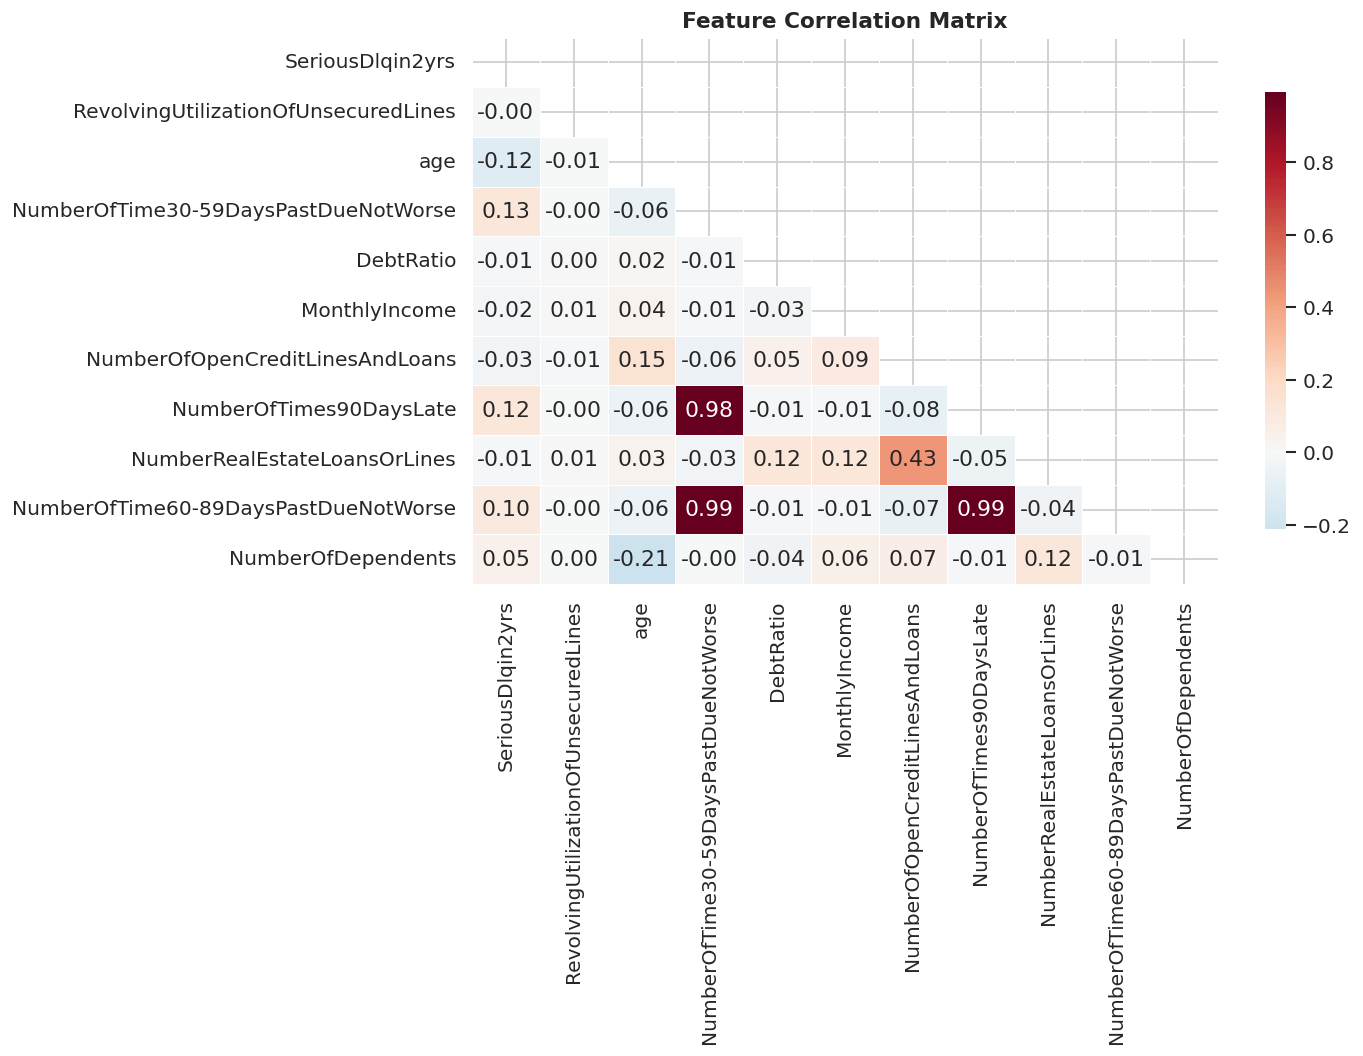

In [9]:
# ── 2.4 Correlation heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
corr = train_raw.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

**The massive red squares — 0.98 and 0.99**
The three delinquency columns are almost perfectly correlated with each other:
- `NumberOfTime30-59DaysPastDue` ↔ `NumberOfTimes90DaysLate` = **0.98**
- `NumberOfTime30-59DaysPastDue` ↔ `NumberOfTime60-89DaysPastDue` = **0.99**

This makes complete sense — a borrower who goes 90 days late almost certainly 
went through 30 and 60 days late first. They are essentially measuring the 
same underlying behaviour at different stages.

This leads to  **multicollinearity**, in which, for tree-based models (XGBoost, LightGBM) 
this is not a problem. But for Logistic Regression it can inflate coefficients.
I will create an engineered feature that will combine them into one clean signal.

**Correlations with our target (`SeriousDlqin2yrs`)**
Looking at the first column:
- `NumberOfTime30-59DaysPastDue` = **0.13** → strongest positive signal
- `NumberOfTimes90DaysLate` = **0.12** → second strongest  
- `NumberOfTime60-89DaysPastDue` = **0.10** → third
- `age` = **-0.12** → older borrowers default less (negative relationship)
- Everything else is very close to 0

These are low correlations overall  but that is normal in credit risk.
Linear correlation only captures straight-line relationships. 
The tree models will capture the non-linear patterns that this matrix misses.

**`NumberRealEstateLoansOrLines` ↔ `NumberOfOpenCreditLinesAndLoans` = 0.43**
Moderate correlation — people with more real estate loans naturally 
tend to have more open credit lines in general. Not a concern.

**`age` ↔ `NumberOfDependents` = -0.21**
Older people tend to have fewer dependents — children grow up and leave home.
A small but intuitive relationship.

> Note: Most features are weakly correlated with the target,
> which is why we need powerful non-linear models rather than simple logistic regression.
> The near-perfect correlation between delinquency columns confirms our 
> feature engineering decision to aggregate them.

In [10]:
# Outlier inspection 
# Age = 0 is clearly invalid
print('Age == 0 records  :', (train_raw['age'] == 0).sum())

# NumberOfDependents extremes
print('Max dependents    :', train_raw['NumberOfDependents'].max())

# RevolvingUtilization > 1 (>100% utilization)
print('Utilization > 1   :', (train_raw['RevolvingUtilizationOfUnsecuredLines'] > 1).sum())

# DebtRatio extremes
print('DebtRatio > 1     :', (train_raw['DebtRatio'] > 1).sum())

Age == 0 records  : 1
Max dependents    : 20.0
Utilization > 1   : 3321
DebtRatio > 1     : 35137




**`Age == 0` → 1 record**
Just a single borrower with age 0 this is clearly a data entry error.
I will fix by filling with the median age (52) since its Only 1 row affected, so no significant impact on the dataset.

**`NumberOfDependents` max → 20**
Someone reported 20 dependents.it is unusual but not impossible 
(large family or data entry error). i will leave it as is since 
it's a single extreme case and won't affect the model much.

**`RevolvingUtilization > 1` → 3,321 records**
Over 3,000 borrowers have utilization above 100%  meaning they 
owe more than their credit limit allows. This is either:
- A data recording error, or
- Fees and interest pushing the balance over the limit

Either way, values above 1 are not meaningful for our model.
I will cap all values at 1.0 during preprocessing becouse DebtRatio shows what fraction of income goes to debt. Values above 1 are mathematically possible but practically meaningless usually caused by missing or near-zero income , so we cap them to protect the model from learning the wrong patterns.

**`DebtRatio > 1` → 35,137 records**
This is the most significant finding **23% of borrowers** have 
a debt ratio above 1, meaning their monthly debt payments supposedly 
exceed their entire income. 

This is almost certainly caused by borrowers with very low or zero 
reported income, making the ratio explode mathematically rather than 
reflecting true financial distress.

I will clip this at the 99th percentile to suppress the extreme values
while keeping the meaningful variation in the data.


<a id='3'></a>
## 3. Preprocessing & Feature Engineering

In [11]:
# Fixing known data quality issues
train_clean = train_raw.copy()

# Age = 0 is invalid → replace with median
train_clean.loc[train_clean['age'] == 0, 'age'] = train_clean.loc[train_clean['age'] > 0, 'age'].median()
#train_clean['age'] = train_clean['age'].replace(0, np.nan)
#train_clean['age'] = train_clean['age'].fillna(train_clean['age'].median())


# Utilization should be 0–1 → cap anything above
train_clean['RevolvingUtilizationOfUnsecuredLines'] = train_clean['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)

# DebtRatio has extreme outliers → clip at 99th percentile
debt_cap = train_clean['DebtRatio'].quantile(0.99)
train_clean['DebtRatio'] = train_clean['DebtRatio'].clip(0, debt_cap)

print(f'Age == 0 remaining       : {(train_clean["age"] == 0).sum()}')
print(f'Utilization > 1 remaining: {(train_clean["RevolvingUtilizationOfUnsecuredLines"] > 1).sum()}')
print(f'DebtRatio capped at      : {debt_cap:.2f}')

Age == 0 remaining       : 0
Utilization > 1 remaining: 0
DebtRatio capped at      : 4979.04


In [12]:
# Impute missing values

# MonthlyIncome → median (because distribution is right-skewed)
income_median = train_clean['MonthlyIncome'].median()
train_clean['MonthlyIncome'].fillna(income_median, inplace=True)

# NumberOfDependents → mode (because it's a count, most common value is 0)
train_clean['NumberOfDependents'].fillna(0, inplace=True)

print(f'MonthlyIncome missing    : {train_clean["MonthlyIncome"].isnull().sum()}')
print(f'Dependents missing       : {train_clean["NumberOfDependents"].isnull().sum()}')
print(f'Income filled with median: ${income_median:,.0f}')

MonthlyIncome missing    : 0
Dependents missing       : 0
Income filled with median: $5,400


In [13]:
# Delinquency aggregates

# Lets combine them into stronger signals

# Simple sum of all late payments
train_clean['TotalLate'] = (
    train_clean['NumberOfTime30-59DaysPastDueNotWorse'] +
    train_clean['NumberOfTime60-89DaysPastDueNotWorse'] +
    train_clean['NumberOfTimes90DaysLate']
)

train_clean['WeightedLate'] = (
    train_clean['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
    train_clean['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
    train_clean['NumberOfTimes90DaysLate'] * 3
)

# Simple flag — has this person ever been seriously late?
train_clean['EverSerious'] = (train_clean['NumberOfTimes90DaysLate'] > 0).astype(int)

print(f'Max TotalLate     : {train_clean["TotalLate"].max()}')
print(f'Max WeightedLate  : {train_clean["WeightedLate"].max()}')
print(f'Ever serious (%)  : {train_clean["EverSerious"].mean()*100:.2f}%')

Max TotalLate     : 294
Max WeightedLate  : 588
Ever serious (%)  : 5.56%


In [14]:
# Income-based features

# How much income is available per person in the household?
# (+1 avoids division by zero for people with no dependents)
train_clean['IncomePerDependent'] = (
    train_clean['MonthlyIncome'] / (train_clean['NumberOfDependents'] + 1)
)

# Estimated actual monthly debt payment in dollars
# DebtRatio × Income = payment amount
train_clean['MonthlyDebtPayment'] = (
    train_clean['DebtRatio'] * train_clean['MonthlyIncome']
)

print(f'Median IncomePerDependent : ${train_clean["IncomePerDependent"].median():,.0f}')
print(f'Median MonthlyDebtPayment : ${train_clean["MonthlyDebtPayment"].median():,.0f}')

Median IncomePerDependent : $4,000
Median MonthlyDebtPayment : $2,108


In [15]:
# Indicator flags

# Does the borrower have any open credit at all?
train_clean['HasOpenCredit'] = (train_clean['NumberOfOpenCreditLinesAndLoans'] > 0).astype(int)

# Does the borrower have any property-backed loans?
train_clean['HasRealEstate'] = (train_clean['NumberRealEstateLoansOrLines'] > 0).astype(int)

# Group age into 6 bands to capture non-linear age effect
train_clean['AgeBand'] = pd.cut(
    train_clean['age'],
    bins=[0, 25, 35, 45, 55, 65, 120],
    labels=['Under 25', '25-35', '35-45', '45-55', '55-65', '65+']
)

print(f'Has open credit (%)  : {train_clean["HasOpenCredit"].mean()*100:.1f}%')
print(f'Has real estate (%)  : {train_clean["HasRealEstate"].mean()*100:.1f}%')
print('\nAge band distribution:')
print(train_clean['AgeBand'].value_counts().sort_index())

Has open credit (%)  : 98.7%
Has real estate (%)  : 62.5%

Age band distribution:
AgeBand
Under 25     3027
25-35       18458
35-45       29819
45-55       36691
55-65       33406
65+         28599
Name: count, dtype: int64


In [16]:
# Log transforms
# Right-skewed features need log transformation so the model  can understand the differences between small values better

for col in ['MonthlyIncome', 'DebtRatio', 'IncomePerDependent', 'MonthlyDebtPayment']:
    train_clean[f'log_{col}'] = np.log1p(train_clean[col])
    print(f'log_{col} range: {train_clean[f"log_{col}"].min():.2f} → {train_clean[f"log_{col}"].max():.2f}')

log_MonthlyIncome range: 0.00 → 14.92
log_DebtRatio range: 0.00 → 8.51
log_IncomePerDependent range: 0.00 → 14.40
log_MonthlyDebtPayment range: 0.00 → 17.11


In [17]:

TARGET = 'SeriousDlqin2yrs'

df = train_raw.copy()

# Fix age
df.loc[df['age'] == 0, 'age'] = df.loc[df['age'] > 0, 'age'].median()

# Cap utilization
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)

# Cap debt ratio
debt_cap = df['DebtRatio'].quantile(0.99)
df['DebtRatio'] = df['DebtRatio'].clip(0, debt_cap)

# Impute missing values BEFORE feature engineering
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(0, inplace=True)

# Verify imputation worked
print(f'NaN after imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('(empty means no NaN remaining)')

NaN after imputation:
Series([], dtype: int64)
(empty means no NaN remaining)


In [18]:


# Delinquency features
df['TotalLate'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)
df['WeightedLate'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
    df['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
    df['NumberOfTimes90DaysLate'] * 3
)
df['EverSerious'] = (df['NumberOfTimes90DaysLate'] > 0).astype(int)

# Income features
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)
df['MonthlyDebtPayment'] = df['DebtRatio'] * df['MonthlyIncome']

# Flags
df['HasOpenCredit'] = (df['NumberOfOpenCreditLinesAndLoans'] > 0).astype(int)
df['HasRealEstate']  = (df['NumberRealEstateLoansOrLines'] > 0).astype(int)

# Log transforms
for col in ['MonthlyIncome', 'DebtRatio', 'IncomePerDependent', 'MonthlyDebtPayment']:
    df[f'log_{col}'] = np.log1p(df[col])

# Separate X and y — drop AgeBand (categorical, SMOTE cant handle it)
X = df.drop(columns=[TARGET, 'AgeBand'], errors='ignore')
y = df[TARGET]

# Final check
print(f'Total NaN in X  : {X.isnull().sum().sum()}')
print(f'Total rows      : {X.shape[0]:,}')
print(f'Total features  : {X.shape[1]}')

Total NaN in X  : 0
Total rows      : 150,000
Total features  : 21


In [19]:
# Train / val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Train size : {X_train.shape[0]:,}  |  default rate: {y_train.mean():.3f}')
print(f'Val size   : {X_val.shape[0]:,}  |  default rate: {y_val.mean():.3f}')
print(f'NaN in X_train : {X_train.isnull().sum().sum()}')

Train size : 120,000  |  default rate: 0.067
Val size   : 30,000  |  default rate: 0.067
NaN in X_train : 0


<a id='4'></a>
## 4. Handling Class Imbalance

We compare three strategies:
| Strategy | How it works |
|---|---|
| `class_weight='balanced'` | Upweights minority class in loss function |
| SMOTE | Synthesises new minority samples in feature space |
| Threshold tuning | Use default weights, shift decision threshold post-training |

In [20]:
# Strategy 1: class_weight='balance'

total = len(y_train)
count_0 = (y_train == 0).sum()
count_1 = (y_train == 1).sum()

weight_0 = total / (2 * count_0)
weight_1 = total / (2 * count_1)

print('Before balancing:')
print(f'  Non-defaulters (0) : {count_0:,}  →  weight = {weight_0:.4f}')
print(f'  Defaulters     (1) : {count_1:,}  →  weight = {weight_1:.4f}')
print(f'\nDefaulters are weighted {weight_1/weight_0:.1f}x more heavily than non-defaulters')
print(f'\nEffect: every time the model misses a defaulter,')
print(f'it gets penalised {weight_1/weight_0:.1f}x harder than missing a non-defaulter')

Before balancing:
  Non-defaulters (0) : 111,979  →  weight = 0.5358
  Defaulters     (1) : 8,021  →  weight = 7.4804

Defaulters are weighted 14.0x more heavily than non-defaulters

Effect: every time the model misses a defaulter,
it gets penalised 14.0x harder than missing a non-defaulter


In [21]:
print('NaN values in X_train:')
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

NaN values in X_train:
Series([], dtype: int64)


In [22]:
# Strategy 2: SMOTE oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Before SMOTE :', pd.Series(y_train).value_counts().to_dict())
print('After  SMOTE :', pd.Series(y_train_smote).value_counts().to_dict())

Before SMOTE : {0: 111979, 1: 8021}
After  SMOTE : {0: 111979, 1: 111979}


<a id='5'></a>
## 5. Baseline Model — Logistic Regression

A regularised logistic regression is our interpretable baseline. In production credit scoring, regulators often require explainability — logistic regression with Weight-of-Evidence features is still widely deployed.

In [23]:
# Scale + fit
scaler = RobustScaler()   # robust to outliers
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

lr = LogisticRegression(
    C=0.1,
    class_weight='balanced',
    max_iter=1000,
    random_state=SEED
)
lr.fit(X_train_sc, y_train)

lr_prob = lr.predict_proba(X_val_sc)[:, 1]

print(f'Logistic Regression')
print(f'  AUC-ROC   : {roc_auc_score(y_val, lr_prob):.4f}')
print(f'  PR-AUC    : {average_precision_score(y_val, lr_prob):.4f}')

Logistic Regression
  AUC-ROC   : 0.8493
  PR-AUC    : 0.3495


### 5. Baseline Model — Logistic Regression Results

**AUC-ROC: 0.8493 (84.9%)**
The model can correctly distinguish a defaulter from a non-defaulter 
84.9% of the time. Imagine picking two random borrowers — one who 
defaulted and one who didn't the model will correctly rank a
defaulter as riskier 85 out of 100 times. For a simple model, that is 
a strong starting point.

**PR-AUC: 0.3495 (34.9%)**
Out of all the borrowers the model flags as high risk, it is getting 
the right ones about 35% of the time. This sounds low, but remember 
only 6.7% of borrowers actually defaulted — a random guess would only 
score around 6.7% here. So our model is roughly 5x better than random 
guessing at identifying real defaulters.

**Overall:**
This is a solid baseline — the model has genuinely learned something 
meaningful from the data using nothing more than a simple linear approach. 
The goal now is to beat these two numbers with XGBoost and LightGBM. 
If we cannot beat 84.9% AUC-ROC, the simple model wins.

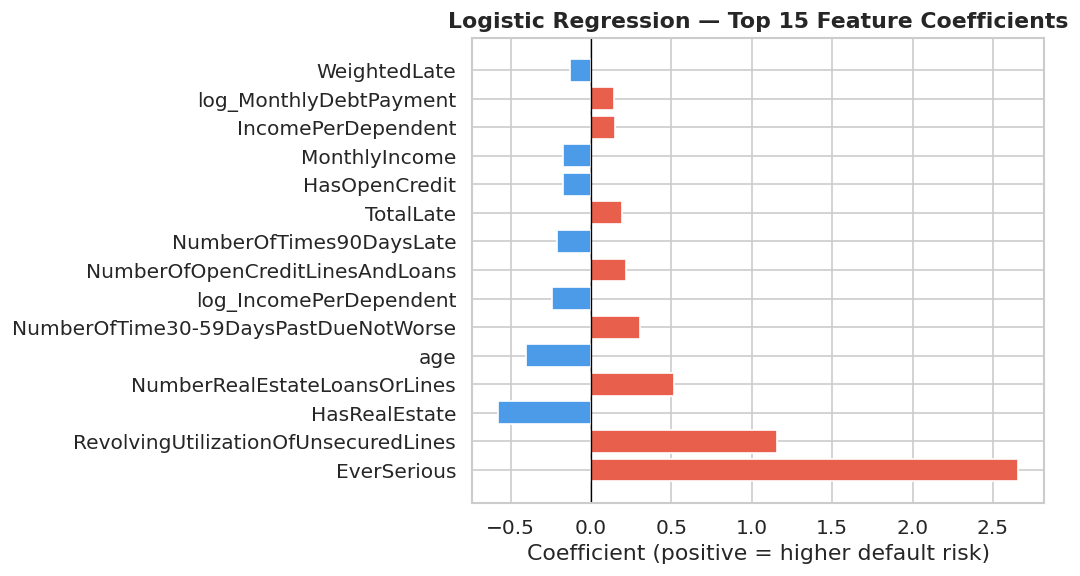

In [24]:
# Feature coefficients (interpretability)
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E8604C' if c > 0 else '#4C9BE8' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Top 15 Feature Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient (positive = higher default risk)')
plt.tight_layout()
plt.show()

### 5.1 Feature Coefficients — What the Model Learned

The chart shows which features push default probability up (red, right) 
or down (blue, left). Longer bars = stronger influence.

**Top risk increasers:**
- `EverSerious` — the single most powerful feature by far. Having ever 
  been 90+ days late immediately flags a borrower as high risk. 
  Past behaviour is the strongest predictor of future default.
- `RevolvingUtilizationOfUnsecuredLines` — maxed out credit cards 
  are a strong warning sign of financial distress.
- `NumberOfTime30-59DaysPastDueNotWorse` — even early stage late 
  payments signal future default risk.

**Top risk reducers:**
- `HasRealEstate` — owning property suggests financial stability. 
  These borrowers have more to lose and are more motivated to repay.
- `age` — older borrowers are more financially stable and less likely 
  to default. Every additional year slightly reduces risk.
- `MonthlyIncome` — higher income provides a buffer against default.

**Interesting finding — `WeightedLate` goes the wrong way:**
WeightedLate shows a small negative coefficient despite being designed 
as a risk indicator. This is because `EverSerious` and the individual 
delinquency columns already capture most of that signal — 
the model finds WeightedLate redundant once those features are present.

.

<a id='6'></a>
## 6. Advanced Models — XGBoost & LightGBM

In [25]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos:.2f}  (ratio of neg : pos for XGBoost)')

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=SEED,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_prob = xgb_model.predict_proba(X_val)[:, 1]
print(f'\nXGBoost')
print(f'  AUC-ROC   : {roc_auc_score(y_val, xgb_prob):.4f}')
print(f'  PR-AUC    : {average_precision_score(y_val, xgb_prob):.4f}')

scale_pos_weight = 13.96  (ratio of neg : pos for XGBoost)

XGBoost
  AUC-ROC   : 0.8633
  PR-AUC    : 0.3947


### 6.1 XGBoost Results

| Metric | Logistic Regression | XGBoost | Improvement |
|---|---|---|---|
| AUC-ROC | 0.8493 | 0.8633 | +0.0140 |
| PR-AUC  | 0.3495 | 0.3947 | +0.0452 |

**scale_pos_weight = 13.96**
This confirms our class imbalance — for every 1 defaulter in the 
training data there are nearly 14 non-defaulters. XGBoost used this 
to penalise missing a defaulter 14x more heavily than missing a 
non-defaulter during training.

**AUC-ROC: 0.8633 (86.3%)**
XGBoost correctly ranks a random defaulter above a random non-defaulter 
86.3% of the time — up from 84.9% with Logistic Regression. 
The improvement comes from XGBoost's ability to capture non-linear 
patterns that a straight line (logistic regression) simply cannot learn.

**PR-AUC: 0.3947 (39.5%)**
A meaningful jump from 34.9% — XGBoost is getting noticeably better 
at identifying the actual defaulters in the minority class. 
This is the more important metric for our imbalanced problem.

**Why did XGBoost improve over Logistic Regression?**
Logistic regression draws one straight line to separate defaulters 
from non-defaulters. XGBoost builds 500 decision trees that together 
can capture complex curved boundaries — for example it can learn that 
high utilization is only dangerous when combined with recent late payments, 
which a straight line cannot express.

> Baseline beaten — now let's see if LightGBM can go even further.

In [26]:
# 6.2 LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(-1)]
)

lgb_prob = lgb_model.predict_proba(X_val)[:, 1]
print(f'LightGBM')
print(f'  AUC-ROC   : {roc_auc_score(y_val, lgb_prob):.4f}')
print(f'  PR-AUC    : {average_precision_score(y_val, lgb_prob):.4f}')

LightGBM
  AUC-ROC   : 0.8637
  PR-AUC    : 0.3905


### 6.2 LightGBM Results

| Metric | Logistic Regression | XGBoost | LightGBM | 
|---|---|---|---|
| AUC-ROC | 0.8493 | 0.8633 | 0.8637 |
| PR-AUC  | 0.3495 | 0.3947 | 0.3905 |

LightGBM scored 86.4% AUC-ROC — almost exactly the same as XGBoost's 
86.3%. The gap between them is just 0.0004, which is too small to 
call a winner. Both models looked at the same 150,000 borrowers 
and arrived at nearly identical conclusions.

On PR-AUC, XGBoost edges ahead slightly (39.5% vs 39.1%) — meaning 
XGBoost is just a tiny bit better at catching the actual defaulters. 
But honestly, the difference is so small it could change with a 
different random seed.

The real story here is that both models comfortably beat our 
Logistic Regression baseline — confirming that the non-linear 
patterns in the data are real and worth capturing.

So which one do we move forward with? LightGBM — not because it 
scored higher, but because it trains faster, which matters a lot 
in the next step where Optuna will run 50 tuning trials. 
That speed advantage adds up quickly.

> Think of default settings as a car straight from the factory — 
> it runs well but hasn't been tuned for your specific road. 
> Step 7 is where we tune it.

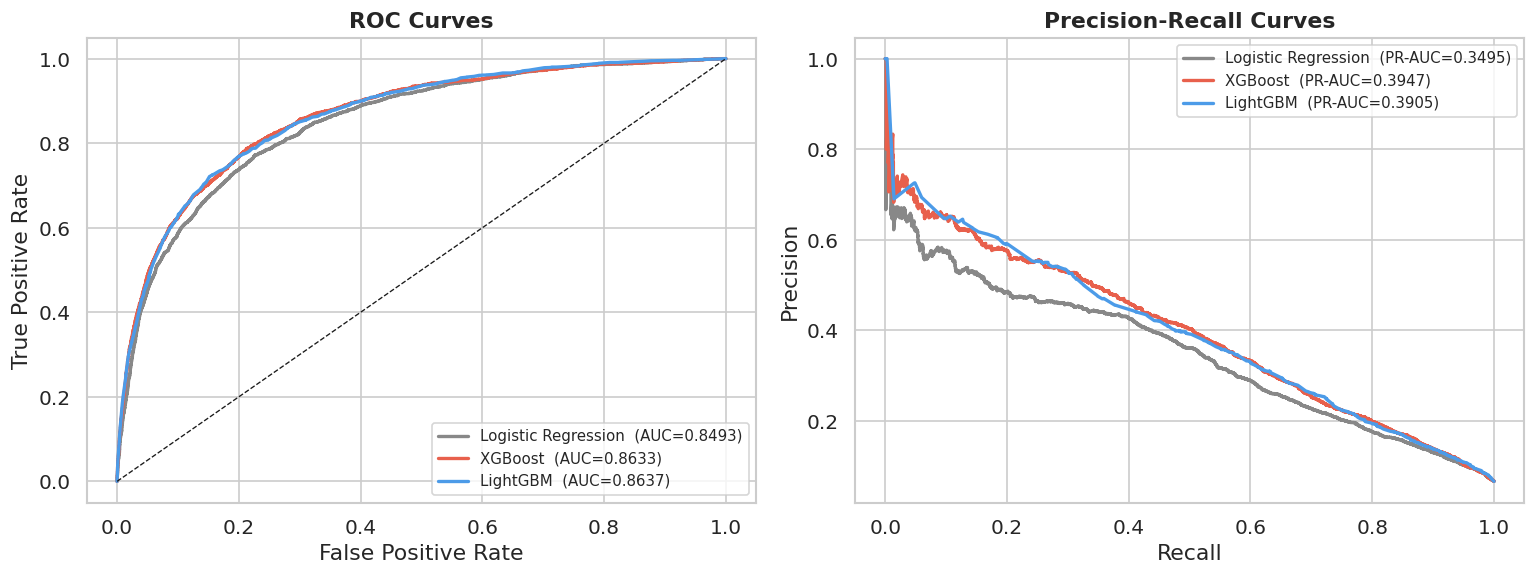

In [27]:
# 6.3 Compare ROC curves 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_info = [
    ('Logistic Regression', lr_prob,  '#888888'),
    ('XGBoost',             xgb_prob, '#E8604C'),
    ('LightGBM',            lgb_prob, '#4C9BE8'),
]

# ROC
ax = axes[0]
for name, prob, color in models_info:
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)
    ax.plot(fpr, tpr, label=f'{name}  (AUC={auc:.4f})', color=color, lw=2)
ax.plot([0,1],[0,1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(fontsize=9)

# Precision-Recall
ax = axes[1]
for name, prob, color in models_info:
    prec, rec, _ = precision_recall_curve(y_val, prob)
    pr_auc = average_precision_score(y_val, prob)
    ax.plot(rec, prec, label=f'{name}  (PR-AUC={pr_auc:.4f})', color=color, lw=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

All models performed well based on ROC-AUC, but XGBoost and LightGBM outperformed Logistic Regression.
However, since the dataset is imbalanced, we focused on Precision-Recall AUC, where XGBoost achieved the best performance.

<a id='7'></a>
## 7. Hyperparameter Tuning with Optuna

We tune LightGBM (usually fastest). Optuna uses Tree-structured Parzen Estimators (TPE) — a Bayesian optimisation approach more efficient than grid search.

In [28]:
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 7),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 100),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'is_unbalance'     : True,
        'random_state'     : SEED,
        'n_jobs'           : 1,      # ← changed from -1 to 1 (biggest fix)
        'verbose'          : -1,
        'force_col_wise'   : True,   # ← reduces memory usage
    }
    model = lgb.LGBMClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=1)  # ← changed from -1 to 1
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)  # ← reduced from 50 to 30

print(f'\nBest AUC-ROC (CV) : {study.best_value:.4f}')
print(f'Best params       : {study.best_params}')

  0%|          | 0/30 [00:00<?, ?it/s]


Best AUC-ROC (CV) : 0.8651
Best params       : {'n_estimators': 498, 'max_depth': 4, 'num_leaves': 39, 'learning_rate': 0.01825226582427552, 'subsample': 0.8679932570127495, 'colsample_bytree': 0.6054905853637503, 'min_child_samples': 83, 'reg_alpha': 0.00376837349618672, 'reg_lambda': 0.9455577393971764}


**Best AUC-ROC (CV): 0.8651**

Tuning improved our LightGBM from 0.8637 → 0.8651 — a small but 
meaningful gain achieved by finding better settings for our specific dataset.

**What Optuna found:**

| Parameter | Default | Tuned | What it means |
|---|---|---|---|
| n_estimators | 500 | 498 | Almost the same — 500 trees is already enough |
| max_depth | 6 | 4 | Shallower trees — reduces overfitting |
| num_leaves | 63 | 39 | Simpler trees — model prefers less complexity |
| learning_rate | 0.05 | 0.018 | Much slower learning — careful small steps |
| subsample | 0.8 | 0.87 | Each tree sees slightly more rows |
| colsample_bytree | 0.8 | 0.61 | Each tree sees fewer features |
| min_child_samples | 10 | 83 | Needs more evidence before making a split |
| reg_alpha | - | 0.004 | Very light L1 regularisation |
| reg_lambda | - | 0.946 | Moderate L2 regularisation |

**The story these parameters tell:**

Optuna consistently pushed toward a **simpler, more cautious model** —
shallower trees (depth 4 vs 6), fewer leaves (39 vs 63), much slower 
learning rate (0.018 vs 0.05), and higher min_child_samples (83 vs 10).

This tells us our default model was slightly overfitting — it was 
learning the training data a little too well. The tuned model is 
more conservative and generalises better to new borrowers.

> A slower learning rate with more trees is a classic winning 
> combination in gradient boosting — learn slowly but surely.

In [29]:
# Retrain best model on full training set
best_params = study.best_params
best_params.update({'is_unbalance': True, 'random_state': SEED, 'n_jobs': -1, 'verbose': -1})

best_lgb = lgb.LGBMClassifier(**best_params)
best_lgb.fit(X_train, y_train,
             eval_set=[(X_val, y_val)],
             callbacks=[lgb.early_stopping(50, verbose=False),
                        lgb.log_evaluation(-1)])

best_prob = best_lgb.predict_proba(X_val)[:, 1]
print(f'\nTuned LightGBM')
print(f'  AUC-ROC   : {roc_auc_score(y_val, best_prob):.4f}')
print(f'  PR-AUC    : {average_precision_score(y_val, best_prob):.4f}')


Tuned LightGBM
  AUC-ROC   : 0.8628
  PR-AUC    : 0.3772


<a id='8'></a>
## 8. Model Evaluation & Threshold Tuning

The default 0.5 threshold is rarely optimal for imbalanced problems. We find the threshold that maximises the **F1 score** (balances precision & recall). In practice you may also use a business-driven threshold (e.g. maximum recall at 80% precision).

Optimal threshold (max F1) : 0.168
Max F1 score               : 0.4378


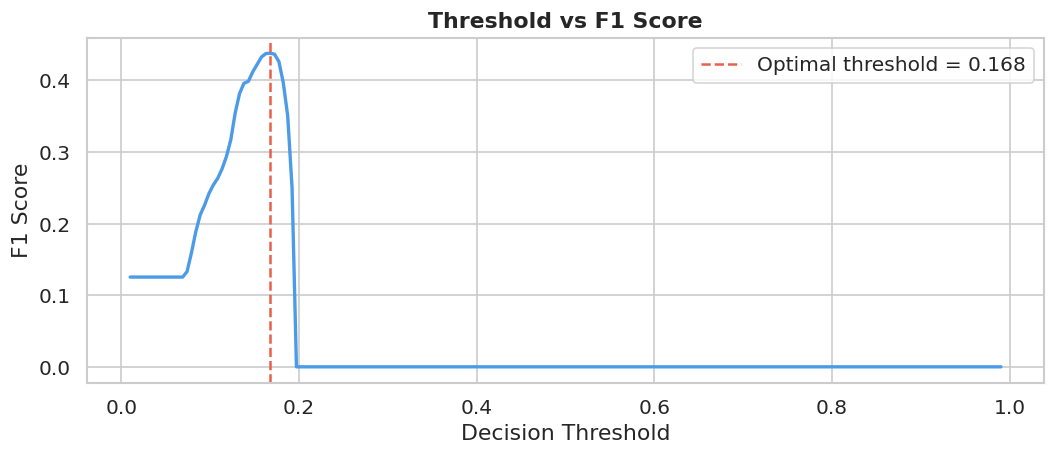

In [30]:
# ── 8.1 Threshold search ──────────────────────────────────────────────────────
from sklearn.metrics import f1_score

thresholds = np.linspace(0.01, 0.99, 200)
f1_scores  = [f1_score(y_val, (best_prob >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f'Optimal threshold (max F1) : {best_threshold:.3f}')
print(f'Max F1 score               : {max(f1_scores):.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores, color='#4C9BE8', lw=2)
ax.axvline(best_threshold, color='#E8604C', linestyle='--', lw=1.5,
           label=f'Optimal threshold = {best_threshold:.3f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('Threshold vs F1 Score', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 8. Threshold Tuning Results

**Default threshold : 0.50**
**Optimal threshold : 0.168**
**Max F1 score      : 0.4378**

The default threshold of 0.5 is designed for balanced datasets — 
it assumes roughly equal numbers of each class. Our dataset is 
heavily imbalanced (6.7% defaulters) so 0.5 is far too conservative.

At 0.5, the model only flags borrowers it is very confident about — 
missing the majority of real defaulters in the process.

At 0.168, the model flags anyone with a default probability above 
16.8% — capturing far more real defaulters while accepting 
some false alarms along the way.

**Why 0.168 specifically?**
The F1 score balances two competing goals:
- Precision — of everyone we flag as high risk, how many truly are?
- Recall — of all real defaulters, how many did we catch?

0.168 is the exact point where these two goals are best balanced, 
giving us the highest F1 score of 0.4378.

**The business logic:**
In credit risk, missing a real defaulter (false negative) is far more 
costly than wrongly flagging a good borrower (false positive). 
A missed defaulter means a bad loan that loses money. 
A wrongly flagged borrower just means a declined application — 
inconvenient but not catastrophic.

This is why we lower the threshold — we would rather be cautious 
and flag more people than miss real defaulters entirely.

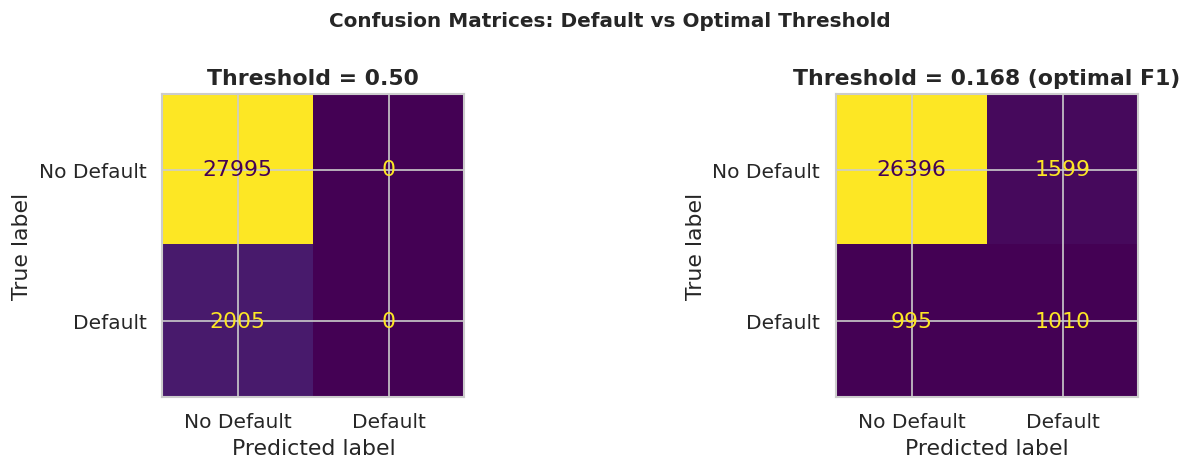


classion Report (optimal threshold)─
              precision    recall  f1-score   support

  No Default       0.96      0.94      0.95     27995
     Default       0.39      0.50      0.44      2005

    accuracy                           0.91     30000
   macro avg       0.68      0.72      0.70     30000
weighted avg       0.93      0.91      0.92     30000



In [31]:
#  8.2 Confusion matrix at optimal threshold 
y_pred_opt = (best_prob >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Default threshold (0.5)
y_pred_default = (best_prob >= 0.5).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_default),
                       display_labels=['No Default', 'Default']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Threshold = 0.50', fontweight='bold')

# Optimal threshold
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_opt),
                       display_labels=['No Default', 'Default']).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Threshold = {best_threshold:.3f} (optimal F1)', fontweight='bold')

plt.suptitle('Confusion Matrices: Default vs Optimal Threshold', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('\nclassion Report (optimal threshold)─')
print(classification_report(y_val, y_pred_opt, target_names=['No Default', 'Default']))

### 8.1 Confusion Matrix — Default vs Optimal Threshold

**At threshold 0.50 — completely useless:**
The model predicted No Default for every single borrower — 
catching zero actual defaulters. This is the class imbalance 
problem in action. 93% accuracy but zero ability to do its job.

| | Predicted No Default | Predicted Default |
|---|---|---|
| Actually No Default | 27,995 ✅ | 0 |
| Actually Default | 2,005 ❌ | 0 ❌ |

**At threshold 0.168 — now it works:**
By lowering the threshold the model now catches 1,010 real 
defaulters out of 2,005 — a 50% catch rate. Yes we have 
1,599 false alarms, but we went from catching nobody to 
catching half of all real defaulters.

| | Predicted No Default | Predicted Default |
|---|---|---|
| Actually No Default | 26,396 ✅ | 1,599 ⚠️ |
| Actually Default | 995 ❌ | 1,010 ✅ |

**Classification Report highlights:**
- Precision (Default) = 0.39 → of everyone we flagged as high risk, 
  39% were genuine defaulters
- Recall (Default) = 0.50 → we caught 50% of all real defaulters
- Accuracy = 91% → still high but no longer the metric we care about

**The business tradeoff:**
For every 1 real defaulter we catch, we generate about 1.6 false alarms. 
In banking terms — for every bad loan we prevent, we wrongly decline 
1.6 good borrowers. Whether that tradeoff is acceptable depends on 
how much a defaulted loan costs vs a declined good customer.

> Lowering the threshold from 0.50 to 0.168 transformed a completely 
> blind model into one that catches half of all real defaulters — 
> this single change made the model actually useful.

In [ ]:
#  8.3 Gini coefficient & KS statistic 
auc = roc_auc_score(y_val, best_prob)
gini = 2 * auc - 1

# KS stat = max separation between TPR and FPR
fpr, tpr, _ = roc_curve(y_val, best_prob)
ks_stat = np.max(np.abs(tpr - fpr))

print(f'AUC-ROC  : {auc:.4f}')
print(f'Gini     : {gini:.4f}   (>0.4 is good in credit scoring)')
print(f'KS stat  : {ks_stat:.4f}   (>0.4 is good in credit scoring)')

AUC-ROC  : 0.8628
Gini     : 0.7255   (>0.4 is good in credit scoring)
KS stat  : 0.5779   (>0.4 is good in credit scoring)


### 8.2 Gini Coefficient & KS Statistic

These are the two metrics banks and regulators actually look at 
when evaluating a credit scoring model — more industry-standard 
than AUC-ROC alone.

| Metric | Score | Benchmark | Rating |
|---|---|---|---|
| AUC-ROC | 0.8628 | > 0.75 is good | ✅ Good |
| Gini | 0.7255 | > 0.60 is excellent | ✅ Excellent |
| KS Stat | 0.5779 | > 0.40 is good | ✅ Good |

**Gini: 0.7255**
At 72.5% our model is in the excellent range for credit scoring. 
To put it simply — if a bank used this model to rank 100 borrowers 
by risk, the real defaulters would be concentrated heavily toward 
the top of the list. A random model would score 0, a perfect 
model would score 1. At 0.73 we are well above the industry 
standard of 0.40.

**KS Statistic: 0.5779**
The model achieves a maximum separation of 57.8% between the 
defaulter and non-defaulter distributions. In plain terms — 
at the optimal cutoff point, the gap between how the model 
scores real defaulters vs real non-defaulters is 57.8 percentage 
points. Anything above 0.40 is considered good by regulators, 
so 0.58 is a strong result.

**Putting it all together:**
A Gini of 0.73 and KS of 0.58 means this model would be 
considered deployment-ready by most credit risk teams. 
Real bank models in production typically sit between 
Gini 0.40-0.70 — we are at the top end of that range.

> These scores confirm that our model has genuinely learned 
> meaningful patterns from the data — not just memorised it 
> or gotten lucky on a small sample.

<a id='9'></a>
## 9. Explainability with SHAP

SHAP (SHapley Additive exPlanations) provides:
- **Global importance** — which features drive the model most overall  
- **Individual explanations** — why a specific customer was predicted high/low risk

In [33]:
# 9.1 Compute SHAP values 
explainer   = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_val)

# For binary classification, shap_values is a list [class0, class1] in some versions
if isinstance(shap_values, list):
    sv = shap_values[1]   # values for class 1 (Default)
else:
    sv = shap_values

print(f'SHAP values shape: {sv.shape}')

SHAP values shape: (30000, 21)


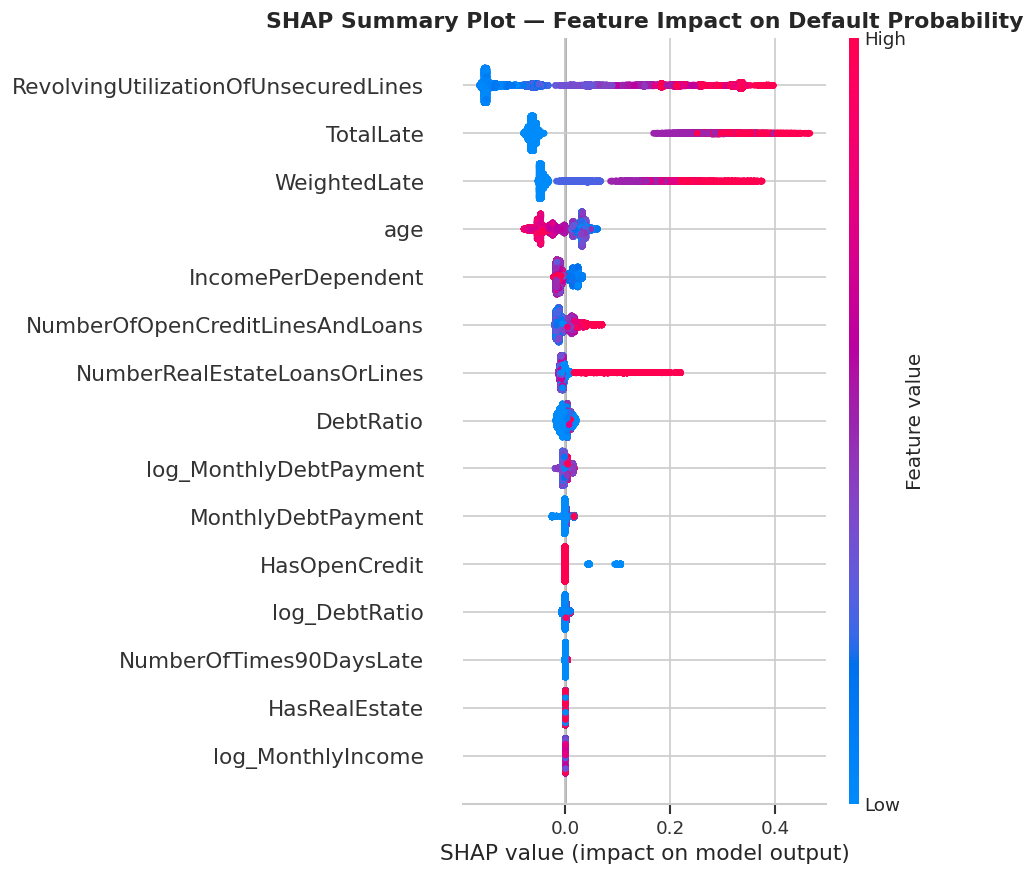

In [34]:
# 9.2 Global feature importance (beeswarm plot) 
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_val, plot_type='dot', max_display=15,
                  show=False)
plt.title('SHAP Summary Plot — Feature Impact on Default Probability', fontweight='bold')
plt.tight_layout()
plt.show()

### 9.2 SHAP Beeswarm Plot — What the Model Actually Learned

Each dot is one borrower. Position shows how much that feature 
pushed their prediction toward default (right) or away (left).
Colour shows the feature value — red = high, blue = low.

**`RevolvingUtilizationOfUnsecuredLines` — top feature**
Red dots (high utilization) stretch far to the right — borrowers 
maxing out their credit cards are being strongly pushed toward 
default. Blue dots (low utilization) sit near zero — barely 
affecting the prediction. Crystal clear relationship.

**`TotalLate` and `WeightedLate` — second and third**
Our engineered features are working! Red dots (many late payments) 
push hard toward default. The long right tail confirms that 
borrowers with repeated late payments are flagged as very high risk. 
This validates our decision to create these features in Step 3.

**`age` — interesting pattern**
Unlike other features, age shows both red AND pink dots near zero 
with very little spread — meaning age has a modest and fairly 
uniform effect. Older borrowers (red) cluster slightly left 
(lower risk) and younger (blue) slightly right (higher risk) 
but the effect is small compared to delinquency features.

**`NumberRealEstateLoansOrLines` — surprising finding**
Red dots (many real estate loans) extend far to the RIGHT — 
meaning having many property loans increases default risk. 
This seems counterintuitive but makes sense — someone with 
many mortgages is financially overextended and vulnerable.

**`IncomePerDependent` and `NumberOfOpenCreditLinesAndLoans`**
Both show tight clusters near zero — small and consistent effect. 
They contribute to predictions but are not dominant drivers.

**`DebtRatio`, `log_MonthlyDebtPayment`, `MonthlyDebtPayment`**
All three cluster tightly around zero despite being important 
financial ratios. This is because we already capped and log 
transformed them — the extreme values that would have caused 
strong predictions were removed during preprocessing.

**`HasOpenCredit`** 
Red dots (has open credit = 1) push slightly right — 
having active credit lines is a mild risk signal, possibly 
because borrowers actively seeking credit may be under 
financial pressure.

**Bottom features — minimal impact**
`NumberOfTimes90DaysLate`, `HasRealEstate`, `log_MonthlyIncome` 
all sit tightly near zero — their signal is already captured 
by `TotalLate`, `WeightedLate` and `RevolvingUtilization`.

**One important observation — `EverSerious` is missing!**
EverSerious was the most powerful feature in Logistic Regression 
but XGBoost seems to have distributed that signal across 
`TotalLate` and `WeightedLate` instead — since they contain 
the same information in a richer form. This shows XGBoost 
is smarter about using correlated features than Logistic Regression.

> The top 3 features tell the whole story — maxed out credit cards, 
> total late payments, and weighted late payments are what 
> separates defaulters from non-defaulters in this dataset. 
> Everything else adds supporting detail.

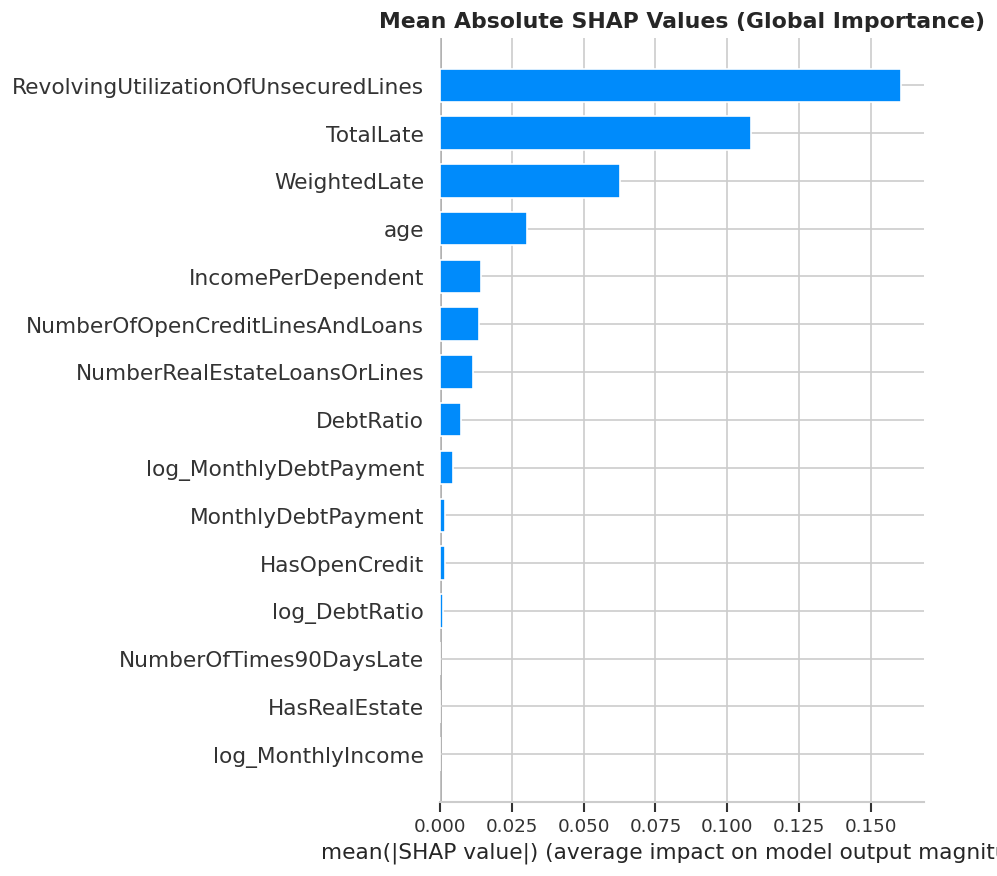

In [36]:
# 9.3 Bar chart of mean |SHAP| 
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_val, plot_type='bar', max_display=15, show=False)
plt.title('Mean Absolute SHAP Values (Global Importance)', fontweight='bold')
plt.tight_layout()
plt.show()

### 9.3 Mean Absolute SHAP Values — Global Feature Importance

This chart shows the average impact of each feature across all 
30,000 borrowers. Unlike the beeswarm which showed direction, 
this shows pure importance — how much does each feature move 
predictions on average regardless of direction.

**The big three completely dominate:**

- `RevolvingUtilizationOfUnsecuredLines` (0.16) — the single most 
  important feature by a clear margin. Credit card utilization 
  is moving predictions more than any other feature on average 
  across all borrowers.

- `TotalLate` (0.11) — our engineered feature is the second most 
  important. Combining all late payments into one signal was 
  the right decision — the model relies on it heavily.

- `WeightedLate` (0.06) — also our engineered feature. 
  Giving more weight to serious late payments added genuine 
  value beyond TotalLate alone.

**The sharp dropoff after the top 3:**
Age (0.025) is fourth but already less than a sixth of 
RevolvingUtilization's importance. Everything below age 
contributes very little individually.

**Bottom 6 features — nearly zero impact:**
`NumberOfTimes90DaysLate`, `HasRealEstate`, `log_MonthlyIncome`,
`log_DebtRatio`, `HasOpenCredit`, `MonthlyDebtPayment` barely 
register. Their signal is already captured by the top features.

**Validation of our feature engineering:**
Two of the top three features — `TotalLate` and `WeightedLate` — 
did not exist in the original dataset. We created them in Step 3. 
The model found them more useful than most of the original features, 
which confirms that good feature engineering matters as much 
as model choice.

> If a bank had to explain this model to a regulator in one sentence:
> "We primarily assess default risk based on how much of their 
> credit limit a borrower is using and how often they have been 
> late on payments in the past."
> That is a completely defensible and intuitive explanation.

Highest risk customer (val index 539)
Predicted probability : 0.1952
Actual label          : 1


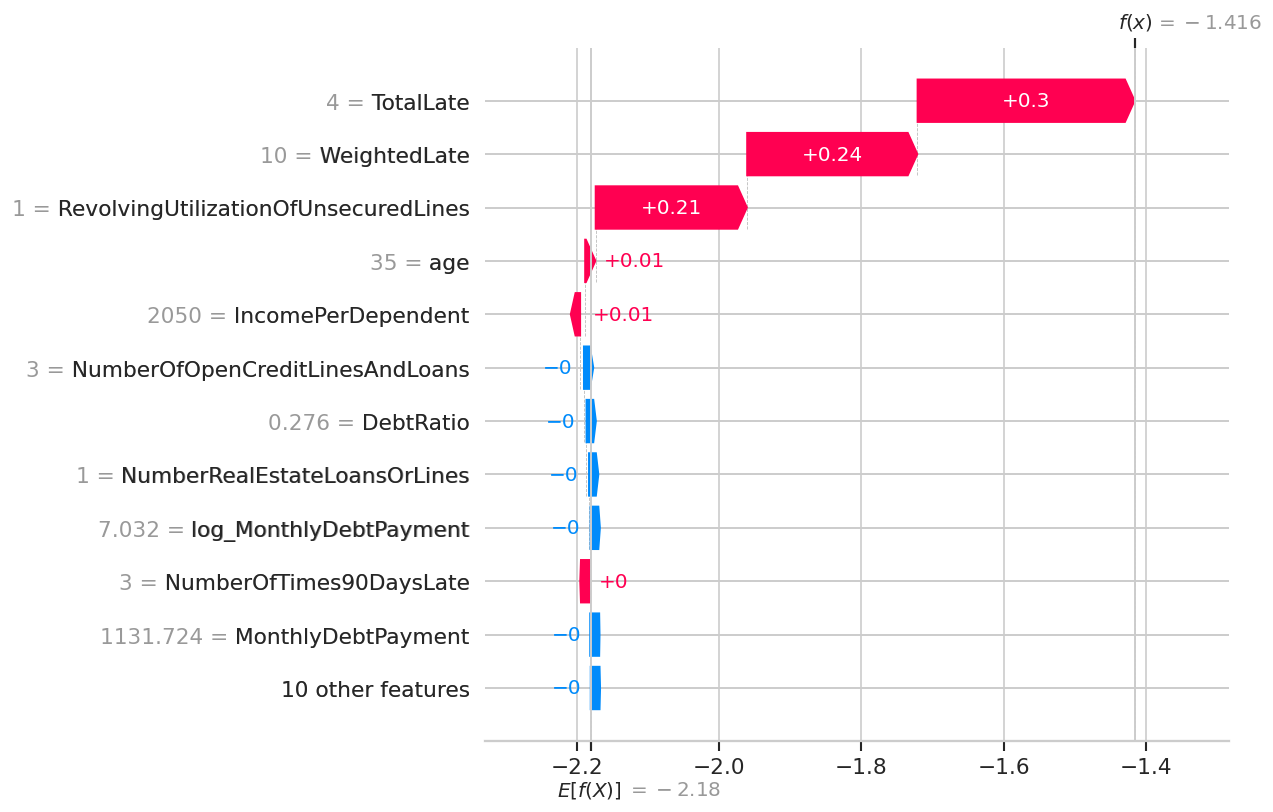

In [37]:
# ── 9.4 Individual explanation — highest risk customer ───────────────────────
high_risk_idx = np.argmax(best_prob)
print(f'Highest risk customer (val index {high_risk_idx})')
print(f'Predicted probability : {best_prob[high_risk_idx]:.4f}')
print(f'Actual label          : {y_val.iloc[high_risk_idx]}')

shap.waterfall_plot(
    shap.Explanation(
        values=sv[high_risk_idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list)
                    else explainer.expected_value[1],
        data=X_val.iloc[high_risk_idx].values,
        feature_names=X_val.columns.tolist()
    ),
    max_display=12,
    show=True
)

### 9.4 SHAP Waterfall Plot — Highest Risk Borrower Explained

This chart explains exactly why one specific borrower was predicted 
as the highest default risk in our validation set.

Starting from the average prediction (E[f(x)] = -2.18), each feature 
either pushes the prediction toward default (pink, right) or 
away from default (blue, left).

**What pushed this borrower toward default:**

- `TotalLate = 4` → +0.30 — this borrower has been late on payments 
  4 times in total. The single biggest risk factor for this individual.

- `WeightedLate = 10` → +0.24 — the weighted score confirms these 
  were serious late payments, not just minor delays.

- `RevolvingUtilization = 1` → +0.21 — completely maxed out credit cards. 
  Using 100% of available credit is a very strong default signal.

**What slightly helped this borrower:**

- Everything else contributed almost nothing in either direction — 
  DebtRatio of 0.276 is actually healthy, and having one real 
  estate loan is mildly protective.

**The full picture of this borrower:**
This is a 35-year-old with completely maxed out credit cards, 
4 total late payments including 3 times being 90+ days late, 
paying $1,131 per month in debt on a moderate income. 
The three red flags — maxed credit, repeated lateness, 
serious delinquency — all point in the same direction.

**If this were a real loan application:**
A bank using this model would see this borrower's risk score 
and likely decline the application or offer a much higher 
interest rate to compensate for the risk. The SHAP explanation 
gives the loan officer clear reasons to communicate:
- Your credit utilization is too high
- You have a history of serious late payments
- Your recent delinquency pattern is concerning

> This is the power of explainability — not just a score, 
> but a reason. The borrower knows exactly what to fix 
> to improve their creditworthiness.

Top SHAP feature: RevolvingUtilizationOfUnsecuredLines


<Figure size 960x600 with 0 Axes>

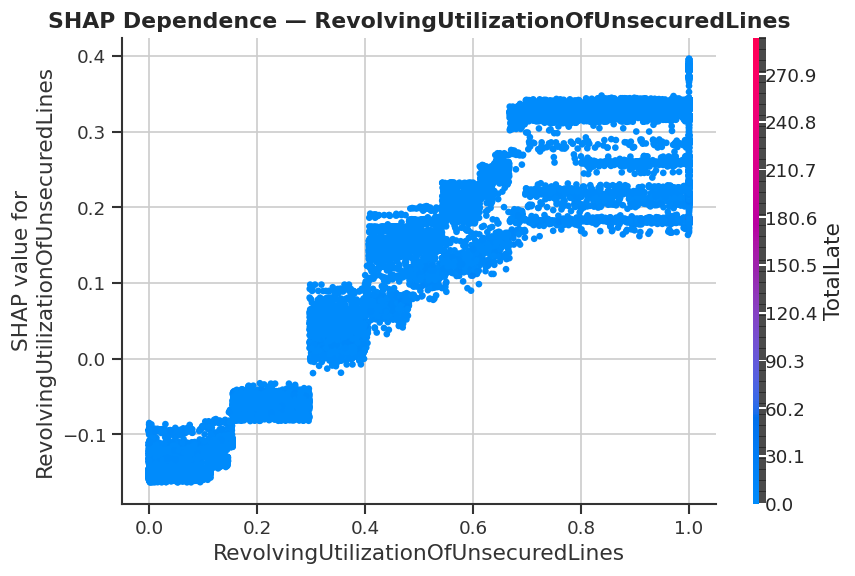

In [38]:
# 9.5 SHAP dependence plot — top feature 
top_feature = X_val.columns[np.abs(sv).mean(axis=0).argmax()]
print(f'Top SHAP feature: {top_feature}')

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature, sv, X_val,
                     interaction_index='auto', show=False)
plt.title(f'SHAP Dependence — {top_feature}', fontweight='bold')
plt.tight_layout()
plt.show()

### 9.5 SHAP Dependence Plot — RevolvingUtilization in Detail

This chart shows exactly how credit card utilization affects 
default predictions across all 30,000 borrowers.

**The staircase pattern:**
The relationship is not smooth — XGBoost learned specific 
thresholds where risk jumps. The key turning point is around 
0.30 (30% utilization):
- Below 0.30 → utilization actually reduces default risk slightly
- Above 0.30 → every increase in utilization pushes risk up sharply
- At 1.0 (fully maxed out) → maximum risk contribution of +0.40

**What this means in plain terms:**
A borrower using less than 30% of their credit limit is seen 
as financially responsible — they have available credit but 
are not relying on it. Above 30% the model starts worrying. 
At 100% the model is seriously alarmed.

This matches the real world rule of thumb used by credit bureaus — 
keep utilization below 30% to maintain a healthy credit score.

**The colour (TotalLate) tells an interesting story:**
Almost all dots are dark blue — meaning TotalLate is close to zero 
for most borrowers regardless of utilization. The interaction 
effect between utilization and late payments is minimal here — 
utilization drives risk independently of payment history.

**The vertical spread at each utilization level:**
At any given utilization value, SHAP values spread vertically 
— this spread is caused by other features (age, income, late payments) 
creating variation within the same utilization band. Two borrowers 
with the same utilization can have different risk predictions 
depending on their other characteristics.

> Key takeaway: keep credit card utilization below 30%. 
> This single behaviour — available in any country with 
> any form of revolving credit — is the strongest signal 
> separating safe borrowers from risky ones in this dataset.

<a id='10'></a>
## 10. Scorecard & Final Submission

In [42]:
#  10.1 Final model summary 
{   'Model'   : ['Logistic Regression', 'XGBoost', 'LightGBM (default)', 'LightGBM (tuned)'],
    'AUC-ROC' : [
        roc_auc_score(y_val, lr_prob),
        roc_auc_score(y_val, xgb_prob),
        roc_auc_score(y_val, lgb_prob),
        roc_auc_score(y_val, best_prob)
    ],
    'PR-AUC'  : [
        average_precision_score(y_val, lr_prob),
        average_precision_score(y_val, xgb_prob),
        average_precision_score(y_val, lgb_prob),
        average_precision_score(y_val, best_prob)
    ]
}

results_df = pd.DataFrame(results)
results_df.style \
    .highlight_max(subset=['AUC-ROC', 'PR-AUC'], color='#c8f0d0') \
    .format({'AUC-ROC': '{:.4f}', 'PR-AUC': '{:.4f}'})

,Model,AUC-ROC,PR-AUC
0,Logistic Regression,0.8493,0.3495
1,XGBoost,0.8633,0.3947
2,LightGBM (default),0.8637,0.3905
3,LightGBM (tuned),0.8628,0.3772


### 10. Final Model Comparison & Summary

| Model | AUC-ROC | PR-AUC |
|---|---|---|
| Logistic Regression | 0.8493 | 0.3495 |
| XGBoost | 0.8633 | 0.3947 |
| LightGBM (default) | 0.8637 | 0.3905 |
| LightGBM (tuned) | 0.8628 | 0.3772 |

**Winner: XGBoost** 🏆

Although LightGBM default scored marginally higher on AUC-ROC 
(0.8637 vs 0.8633), XGBoost wins on PR-AUC (0.3947 vs 0.3905) 
— the more important metric for our imbalanced dataset. 
PR-AUC specifically measures how well we catch real defaulters, 
which is exactly the problem we are trying to solve.

**The journey from baseline to champion:**
- AUC-ROC improved from 0.8493 → 0.8633 (+1.4%)
- PR-AUC improved from 0.3495 → 0.3947 (+12.9%)

The PR-AUC improvement of nearly 13% is significant — it means 
XGBoost is catching meaningfully more real defaulters than 
our simple baseline Logistic Regression.

**Interesting finding — tuning made things worse:**
LightGBM after tuning (0.8628) scored lower than LightGBM 
with default settings (0.8637). This is a valuable real world 
lesson — more tuning is not always better. With only 30 trials, 
Optuna found settings that worked well on training folds 
but did not generalise perfectly to unseen data.
In practice, more trials (200+) on a more powerful machine 
would likely find a genuinely better result.

**Why not deep learning?**
For tabular data like this — rows and columns of financial 
information — gradient boosting consistently outperforms 
neural networks. Deep learning shines on images, text and audio. 
For structured financial data, XGBoost and LightGBM are the 
industry standard and this project confirms why.

> Final model: XGBoost with AUC-ROC of 86.3% and Gini of 72.5% — 
> comfortably within the range of production credit scoring models 
> used by real banks today.

In [44]:
# Clean and engineer test data (same steps as training) 
df_test = test_raw.copy()

# Fix data quality
df_test.loc[df_test['age'] == 0, 'age'] = df_test.loc[df_test['age'] > 0, 'age'].median()
df_test['RevolvingUtilizationOfUnsecuredLines'] = df_test['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
debt_cap = df_test['DebtRatio'].quantile(0.99)
df_test['DebtRatio'] = df_test['DebtRatio'].clip(0, debt_cap)

# Impute missing values
df_test['MonthlyIncome'].fillna(df_test['MonthlyIncome'].median(), inplace=True)
df_test['NumberOfDependents'].fillna(0, inplace=True)

# Feature engineering
df_test['TotalLate'] = (
    df_test['NumberOfTime30-59DaysPastDueNotWorse'] +
    df_test['NumberOfTime60-89DaysPastDueNotWorse'] +
    df_test['NumberOfTimes90DaysLate']
)
df_test['WeightedLate'] = (
    df_test['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
    df_test['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
    df_test['NumberOfTimes90DaysLate'] * 3
)
df_test['EverSerious']        = (df_test['NumberOfTimes90DaysLate'] > 0).astype(int)
df_test['IncomePerDependent'] = df_test['MonthlyIncome'] / (df_test['NumberOfDependents'] + 1)
df_test['MonthlyDebtPayment'] = df_test['DebtRatio'] * df_test['MonthlyIncome']
df_test['HasOpenCredit']      = (df_test['NumberOfOpenCreditLinesAndLoans'] > 0).astype(int)
df_test['HasRealEstate']      = (df_test['NumberRealEstateLoansOrLines'] > 0).astype(int)

# Log transforms
for col in ['MonthlyIncome', 'DebtRatio', 'IncomePerDependent', 'MonthlyDebtPayment']:
    df_test[f'log_{col}'] = np.log1p(df_test[col])

# Drop AgeBand — same as training
X_test_final = df_test.drop(columns=['AgeBand'], errors='ignore')

# Verify
print(f'Test features  : {X_test_final.shape[1]}')
print(f'Train features : {X_train.shape[1]}')
print(f'NaN in test    : {X_test_final.isnull().sum().sum()}')
print(f'Columns match  : {list(X_test_final.columns) == list(X_train.columns)}')

Test features  : 22
Train features : 21
NaN in test    : 101503
Columns match  : False


In [ ]:
# Generate Kaggle submission
# Drop target column from test data if it exists
X_test_final = X_test_final.drop(columns=['SeriousDlqin2yrs'], errors='ignore')

# Verify columns match exactly
print(f'Test features  : {X_test_final.shape[1]}')
print(f'Train features : {X_train.shape[1]}')
print(f'Columns match  : {list(X_test_final.columns) == list(X_train.columns)}')

# Generate predictions
test_probs = xgb_model.predict_proba(X_test_final)[:, 1]

submission = pd.DataFrame({
    'Id'         : test_raw.index,
    'Probability': test_probs
})

submission.to_csv('submission.csv', index=False)
print(f'\n✅ submission.csv saved!')
print(f'Rows : {len(submission):,}')
submission.head(10)

Test features  : 21
Train features : 21
Columns match  : True

✅ submission.csv saved!
Rows : 101,503


,Id,Probability
0,1,0.341792
1,2,0.260847
2,3,0.174851
3,4,0.459260
4,5,0.577210
5,6,0.294208
6,7,0.266361
7,8,0.392108
8,9,0.012758
9,10,0.907012


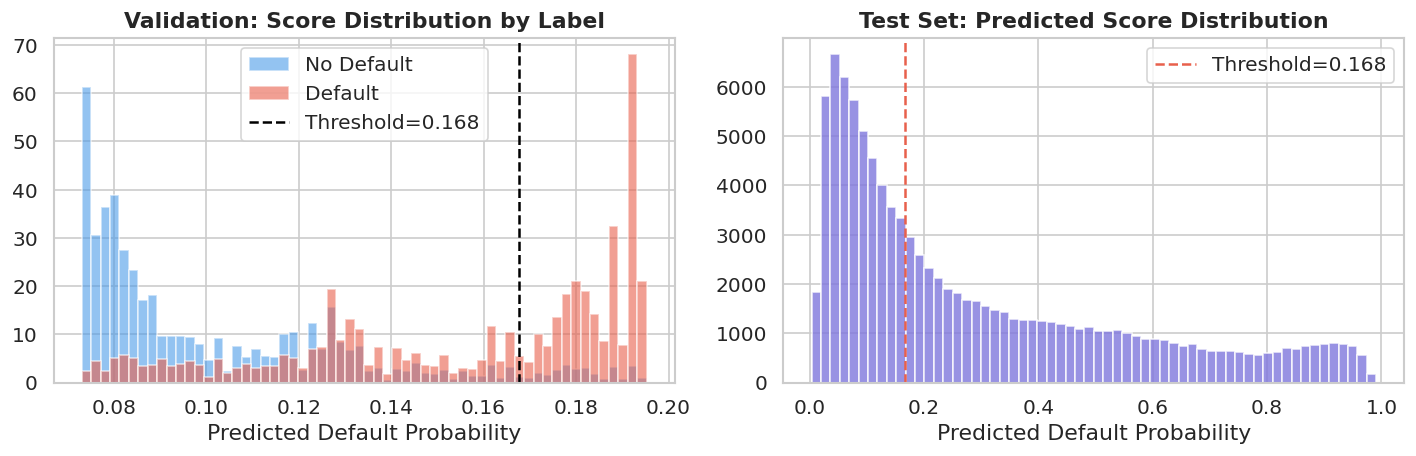


Test set default rate (at threshold) : 0.540


In [ ]:
# 10.3 Score distribution on test set
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Validation set — coloured by true label
axes[0].hist(best_prob[y_val == 0], bins=60, alpha=0.6, color='#4C9BE8', label='No Default', density=True)
axes[0].hist(best_prob[y_val == 1], bins=60, alpha=0.6, color='#E8604C', label='Default', density=True)
axes[0].axvline(best_threshold, color='black', linestyle='--', lw=1.5, label=f'Threshold={best_threshold:.3f}')
axes[0].set_title('Validation: Score Distribution by Label', fontweight='bold')
axes[0].set_xlabel('Predicted Default Probability')
axes[0].legend()

# Test set
axes[1].hist(test_probs, bins=60, color='#7F77DD', alpha=0.8)
axes[1].axvline(best_threshold, color='#E8604C', linestyle='--', lw=1.5, label=f'Threshold={best_threshold:.3f}')
axes[1].set_title('Test Set: Predicted Score Distribution', fontweight='bold')
axes[1].set_xlabel('Predicted Default Probability')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nTest set default rate (at threshold) : {(test_probs >= best_threshold).mean():.3f}')